In [64]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import csv
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,IsolationForest
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN,AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE



In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
uber_data=pd.read_csv('/content/drive/MyDrive/Machine learning files/datasets/Uber-Jan-Feb-FOIL.csv')
uber_data.head()

,dispatching_base_number,date,active_vehicles,trips
0,B02512,1/1/2015,190,1132
1,B02765,1/1/2015,225,1765
2,B02764,1/1/2015,3427,29421
3,B02682,1/1/2015,945,7679
4,B02617,1/1/2015,1228,9537


In [67]:
uber_data['dispatching_base_number']=uber_data['dispatching_base_number'].str.replace('B','').astype(int)
uber_data.head()

,dispatching_base_number,date,active_vehicles,trips
0,2512,1/1/2015,190,1132
1,2765,1/1/2015,225,1765
2,2764,1/1/2015,3427,29421
3,2682,1/1/2015,945,7679
4,2617,1/1/2015,1228,9537


In [68]:
uber_data['date']=pd.to_datetime(uber_data['date'])
uber_data['year']=uber_data['date'].dt.year
uber_data['day']=uber_data['date'].dt.day
uber_data['week']=uber_data['date'].dt.weekday
uber_data['month']=uber_data['date'].dt.month
uber_data.head()

,dispatching_base_number,date,active_vehicles,trips,year,day,week,month
0,2512,2015-01-01,190,1132,2015,1,3,1
1,2765,2015-01-01,225,1765,2015,1,3,1
2,2764,2015-01-01,3427,29421,2015,1,3,1
3,2682,2015-01-01,945,7679,2015,1,3,1
4,2617,2015-01-01,1228,9537,2015,1,3,1


In [69]:
uber_data=uber_data.drop('date',axis=1)
uber_data.head()

,dispatching_base_number,active_vehicles,trips,year,day,week,month
0,2512,190,1132,2015,1,3,1
1,2765,225,1765,2015,1,3,1
2,2764,3427,29421,2015,1,3,1
3,2682,945,7679,2015,1,3,1
4,2617,1228,9537,2015,1,3,1


In [70]:
x=uber_data.iloc[:,0:]

In [71]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

INERTIA VS SILHOUTTE

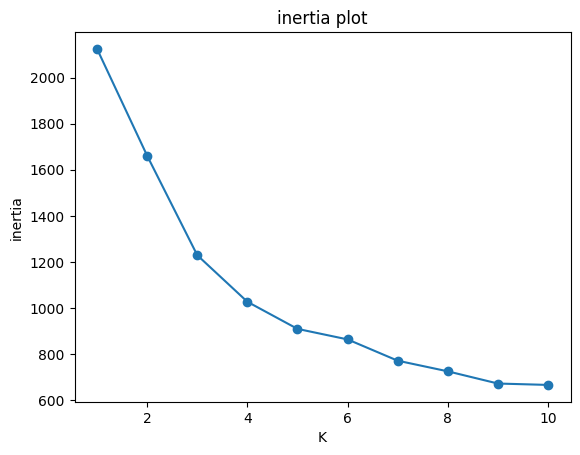

In [72]:
inertia_list=[]
for k in range(1,11):
  model1=KMeans(n_clusters=k)
  labels=model1.fit_predict(x_scaled)
  inertia_list.append(model1.inertia_)
plt.plot(range(1,11),inertia_list,marker='o')
plt.xlabel('K')
plt.title("inertia plot")
plt.ylabel('inertia')
plt.show()

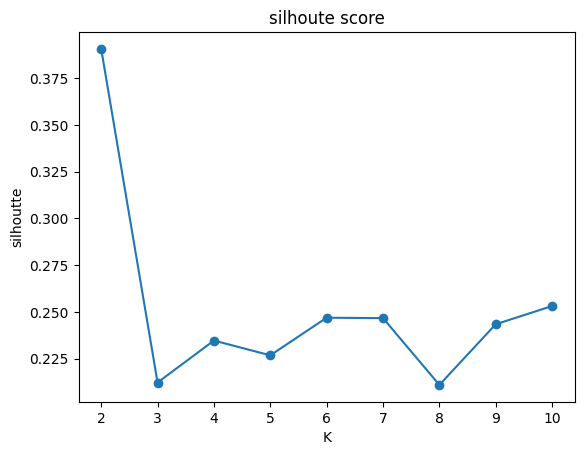

In [73]:
silhooute=[]
for k in range(2,11):
  model2=KMeans(n_clusters=k)
  labels=model2.fit_predict(x_scaled)
  score=silhouette_score(x_scaled,labels)
  silhooute.append(score)
plt.plot(range(2,11),silhooute,marker='o')
plt.xlabel('K')
plt.ylabel('silhoutte')
plt.title('silhoute score')
plt.show()



KMEANS MODEL BEST CLUSTER IS 2

In [74]:
model3=KMeans(n_clusters=2)
model3.fit(x_scaled)

KMeans(n_clusters=2)

In [75]:
labelk=model3.predict(x_scaled)
uber_data['k,labels']=labelk
uber_data.head()

,dispatching_base_number,active_vehicles,trips,year,day,week,month,"k,labels"
0,2512,190,1132,2015,1,3,1,0
1,2765,225,1765,2015,1,3,1,0
2,2764,3427,29421,2015,1,3,1,1
3,2682,945,7679,2015,1,3,1,0
4,2617,1228,9537,2015,1,3,1,0


In [76]:
uber_data.groupby('k,labels').mean()

,dispatching_base_number,active_vehicles,trips,year,day,week,month
"k,labels",,,,,,,
0,2635.236486,835.003378,7526.280405,2015.0,15.327703,3.043919,1.472973
1,2764.000000,3718.465517,32800.879310,2015.0,15.086207,3.086207,1.482759


DBSCAN

In [77]:
model4=DBSCAN(eps=2)
labels_dbs=model4.fit_predict(x_scaled)


In [78]:
noise=len(set(labels_dbs ))-(1 if -1 in labels_dbs else 0)
noise

3

In [79]:
counting_noise=list(labels_dbs).count(-1)
counting_noise

0

In [80]:
uber_data['DBSCAN']=labels_dbs

In [81]:
uber_data.groupby('DBSCAN').mean()

,dispatching_base_number,active_vehicles,trips,year,day,week,month,"k,labels"
DBSCAN,,,,,,,,
0,2656.333333,1216.854839,10261.553763,2015.0,16.0,3.096774,1.0,0.16129
1,2634.800000,913.821429,8736.485714,2015.0,14.5,3.000000,2.0,0.00000
2,2764.000000,3877.214286,35659.750000,2015.0,14.5,3.000000,2.0,1.00000


PCA REDUCING COLUMNS

In [93]:
reduction=PCA(n_components=3)
x_pca=reduction.fit_transform(x_scaled)

In [94]:
reduction.explained_variance_ratio_

array([0.39588147, 0.18274428, 0.16570728])

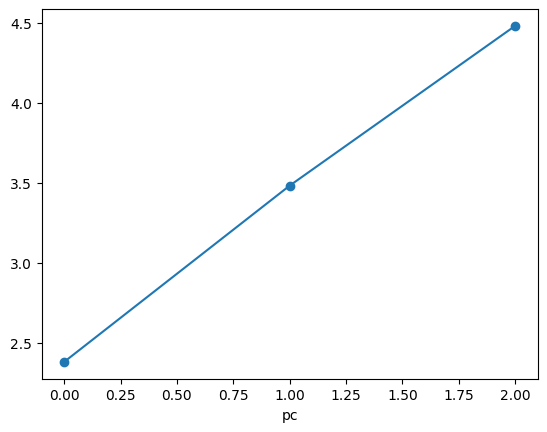

In [95]:
plt.plot(np.cumsum(reduction.explained_variance_),marker='o')
plt.xlabel('pc')
plt.show()

In [102]:
new_uber_data=pd.DataFrame(x_pca)
new_uber_data

,0,1,2
0,-2.089719,0.577818,0.360967
1,-0.762154,0.433048,0.005666
2,2.573883,0.406961,0.008022
3,-0.445943,0.474529,0.121650
4,-0.511763,0.509488,0.210991
...,...,...,...
349,3.808434,-0.671422,0.680528
350,0.171774,-0.564697,0.872804
351,0.532399,-0.602029,0.782510
352,-1.685798,-0.494359,1.010954


T-SNE

In [105]:
model6=IsolationForest(contamination=0.5)
labels10=model6.fit_predict(x_scaled)

In [106]:
nomarl=(labels10==1).sum()
unnomarl=(labels10==-1).sum()

In [107]:
nomarl

np.int64(177)

In [108]:
unnomarl

np.int64(177)